In [ ]:
# 讀取資料，擷取 2018~2023 年的 CSV 資料
import pandas as pd

name = ["古亭", "士林", "大同", "中山", "松山", "萬華", "陽明"] # 七個測站中文名稱
eng_name = ["GUTIN", "SHILIN", "DATON", "ZHONGSHAN", "SONGSHANG", "WANHUA", "YANGMIN"] # 七個測站英文名稱
store_dict = {} # 建立空dict儲存不同測站&年份的資料

# 設定基礎路徑 
base_path = "/Users/kai_0514/Documents/Python/final project_air pollution/北部空品區_"

for i in range(len(name)): # 依照中文名稱讀取檔案
    for j in range(2018, 2024): # 擷取 2018 年到 2023 年的資料
        # 建立完整檔案路徑
        file_path = f"{base_path}{j}/{name[i]}_{j}.csv"
        
        # 讀取 2018~2023 年的 CSV 資料
        store_dict[f"{eng_name[i]}_{j}"] = pd.read_csv(file_path, encoding="utf-8")
        
        # 刪除第一列資料 (通常是單位或說明文字)
        store_dict[f"{eng_name[i]}_{j}"] = store_dict[f"{eng_name[i]}_{j}"].drop([0])

In [ ]:
# 資料前處理：清理空格、統一格式並過濾不需要的數字欄位
for key in store_dict:
    df = store_dict[key]
    
    # 1. 清理欄位名稱 (Column Index) 的空格
    df.columns = df.columns.str.strip()
    
    # 2. 針對所有字串類型的欄位（Object）進行批次 strip()
    df_obj = df.select_dtypes(['object'])
    df[df_obj.columns] = df_obj.apply(lambda x: x.str.strip())
    
    # 3. 刪除「純數字」或「小時」欄位
    hour_cols = [str(i) for i in range(24)] # 產生 ['0', '1', ..., '23']
    # 檢查這些欄位是否存在，存在才刪除
    df = df.drop(columns=[col for col in hour_cols if col in df.columns])
    
    # 4. 強制轉換特定欄位類型
    
    store_dict[key] = df
    print(f"專案 {key} 前處理完成，剩餘欄位數: {len(df.columns)}")

In [ ]:
# 資料前處理：篩選指定汙染物與氣象因子
target_metrics = ["NO2", "O3", "PM10", "PM2.5", "SO2", "CO", "WIND_SPEED", "AMB_TEMP", "RAINFALL"]

for key in store_dict:
    df = store_dict[key]
    
    df_filtered = df[df["測項"].isin(target_metrics)].copy()
    
    # 重設索引，drop=True 避免產生多餘的 'index' 欄位
    df_filtered = df_filtered.reset_index(drop=True)
    
    store_dict[key] = df_filtered
    print(f"測站 {key}: 已篩選出 {len(target_metrics)} 類目標測項")

In [ ]:
# 資料前處理：日期轉換
for key in store_dict:
    df = store_dict[key]
    
    # 1. 將「日期」欄位轉換為真正的 Datetime 物件
    # errors='coerce' 可以自動處理格式錯誤的日期
    df['日期_dt'] = pd.to_datetime(df['日期'], errors='coerce')
    
    # 2. 利用 .dt 存取器快速擷取年、月、日
    df['年分'] = df['日期_dt'].dt.year
    df['月份'] = df['日期_dt'].dt.month
    df['日數'] = df['日期_dt'].dt.day
    
    # 3. 建立「月份+日期」用於季節性分析 
    df['月份+日期'] = df['日期_dt'].dt.strftime('%m-%d')
    
    # 4. 覆蓋原始的「日期」欄位為標準格式 (YYYY-MM-DD)
    df['日期'] = df['日期_dt'].dt.strftime('%Y-%m-%d')
    
    # 刪除過度工具欄位並存回
    df = df.drop(columns=['日期_dt'])
    store_dict[key] = df
    
    print(f"測站 {key}: 日期標準化完成")

In [40]:
import pandas as pd
import numpy as np

# --- 步驟 1：將同測站的所有年份資料合併，解決「跨年」邊界問題 ---
def merge_and_calculate_aqi(eng_name_list, store_dict):
    final_results = {}
    
    for station in eng_name_list:
        # 提取該測站所有年份的 Key (例如 GUTIN_2018, GUTIN_2019...)
        station_keys = sorted([k for k in store_dict.keys() if station in k])
        
        if not station_keys:
            continue
            
        # 縱向合併資料表
        station_df = pd.concat([store_dict[k] for k in station_keys], ignore_index=True)
        
        # 確保日期排序正確，這是計算移動平均的前提
        station_df = station_df.sort_values(["日期", "測項"]).reset_index(drop=True)
        
        # --- 步驟 2：針對 CO 進行長格式轉換與移動平均計算 ---
        co_data = station_df[station_df["測項"] == "CO"].copy()
        
        # 定義小時欄位 (00, 01...23)
        hour_cols = [f"{i:02d}" for i in range(24)]
        
        # 將 24 欄轉為 1 欄 (Melt)，資料會變成：日期1-00點, 日期1-01點...日期2-00點
        # 這樣資料就變成一條「不斷點」的長龍
        co_melted = co_data.melt(id_vars=['日期'], value_vars=hour_cols, var_name='Hour', value_name='Value')
        co_melted['Value'] = pd.to_numeric(co_melted['Value'], errors='coerce')
        
        # 依照日期與小時排序，確保時間連續
        co_melted = co_melted.sort_values(['日期', 'Hour']).reset_index(drop=True)
        
        # 使用 rolling(8) 直接計算前 8 小時平均，Pandas 會自動跨日、跨年計算
        # min_periods=6 確保即使少了 1-2 小時也能計算
        co_melted['CO_8hr_Avg'] = co_melted['Value'].rolling(window=8, min_periods=6).mean()
        
        # --- 步驟 3：AQI 數值轉換 (線性插值) ---
        def get_co_aqi(conc):
            if pd.isna(conc): return np.nan
            # 使用 numpy 的 interp 進行專業的分段線性插值
            xp = [0, 4.4, 9.4, 12.4, 15.4, 30.4, 40.4, 50.4] # 濃度分界
            fp = [0, 50, 100, 150, 200, 300, 400, 500]      # 對應 AQI 分界
            return np.interp(conc, xp, fp)

        co_melted['CO_AQI'] = co_melted['CO_8hr_Avg'].apply(get_co_aqi)
        
        # --- 步驟 4：轉回你需要的格式 (日期為 Key，24 小時 AQI 為 List) ---
        # 重新排序確保轉回 list 時小時順序正確 (00->23)
        station_aqi_dict = co_melted.sort_values(['日期', 'Hour']).groupby('日期')['CO_AQI'].apply(list).to_dict()
        
        final_results[station] = station_aqi_dict
        print(f"測站 {station}: 跨年份 AQI 計算完成！")
        
    return final_results

# 執行合併計算
# eng_name = ["GUTIN", "SHILIN", "DATON", "ZHONGSHAN", "SONGSHANG", "WANHUA", "YANGMIN"]
# final_aqi_data = merge_and_calculate_aqi(eng_name, store_dict)

In [58]:
def SO2_AQI_COUNT_OPTIMIZED(station_df):
    # 1. 自動偵測現有的數字欄位作為小時
    all_cols = station_df.columns.tolist()
    # 找出所有是純數字字串的欄位 (例如 '00', '01'...)
    hour_cols = [c for c in all_cols if str(c).isdigit()]
    
    if not hour_cols:
        raise ValueError("錯誤：找不到任何小時數字欄位，請檢查資料讀取是否正確。")

    # 2. 進行長格式轉換
    so2_data = station_df[station_df["測項"] == "SO2"].copy()
    
    # 使用我們動態偵測到的 hour_cols，有多少算多少
    so2_melted = so2_data.melt(
        id_vars=['日期'], 
        value_vars=hour_cols, 
        var_name='Hour', 
        value_name='Value'
    )
    
    # 3. 數值清理：處理可能的無效字元 (如 #, *, x)
    so2_melted['Value'] = pd.to_numeric(so2_melted['Value'], errors='coerce')
    so2_melted = so2_melted.sort_values(['日期', 'Hour']).reset_index(drop=True)

    # 4. 滾動計算 (其餘邏輯維持不變)
    so2_melted['SO2_24hr_Avg'] = so2_melted['Value'].rolling(window=24, min_periods=6).mean()

    def so2_to_aqi(row):
        conc = row['Value']
        avg_24h = row['SO2_24hr_Avg']
        if pd.isna(conc): return np.nan
        xp = [0, 35, 75, 185, 305, 605, 805, 1005]
        fp = [0, 50, 100, 150, 200, 300, 400, 500]
        # 依照法規，濃度低看小時值，高看24小時值
        if conc < 185:
            return np.interp(conc, xp[:4], fp[:4])
        else:
            return np.interp(avg_24h, xp[3:], fp[3:])

    so2_melted['SO2_AQI'] = so2_melted.apply(so2_to_aqi, axis=1)
    return so2_melted.groupby('日期')['SO2_AQI'].apply(list).to_dict()

In [74]:
import pandas as pd
import numpy as np

def NO2_AQI_COUNT_OPTIMIZED(station_df):
    """
    station_df: 已經 pd.concat 過的多年份資料
    """
    # --- [核心修正] 自動檢查並補齊 00-23 欄位，防止 KeyError ---
    hour_cols = [f"{i:02d}" for i in range(24)]
    for col in hour_cols:
        if col not in station_df.columns:
            station_df[col] = np.nan
    # -----------------------------------------------------

    # 1. 篩選 NO2 並轉為長格式 (Melt)
    no2_data = station_df[station_df["測項"] == "NO2"].copy()
    
    # 因為上方已補齊欄位，這裡的 value_vars 絕對安全
    no2_melted = no2_data.melt(id_vars=['日期'], value_vars=hour_cols, var_name='Hour', value_name='Value')
    
    # 數值清理：將無效字元轉為 NaN 並確保時間排序正確
    no2_melted['Value'] = pd.to_numeric(no2_melted['Value'], errors='coerce')
    no2_melted = no2_melted.sort_values(['日期', 'Hour']).reset_index(drop=True)

    # 2. AQI 數值轉換 (線性插值)
    def no2_to_aqi(conc):
        if pd.isna(conc): return np.nan
        
        # 定義 NO2 濃度分界與對應 AQI 分界
        # 注意：NO2 的 AQI 是直接根據小時濃度計算（不像 PM2.5 需要移動平均）
        xp = [0, 30, 100, 360, 650, 1250, 1650, 2049] # 濃度 (ppb)
        fp = [0, 50, 100, 150, 200, 300, 400, 500]   # AQI
        
        return np.interp(conc, xp, fp)

    no2_melted['NO2_AQI'] = no2_melted['Value'].apply(no2_to_aqi)

    # 3. 轉回你原本需要的格式 {日期: [24小時的AQI list]}
    # 加入 round 確保數值整齊，並處理 NaN 避免錯誤
    result_dict = no2_melted.groupby('日期')['NO2_AQI'].apply(
        lambda x: [round(i, 1) if not pd.isna(i) else np.nan for i in x]
    ).to_dict()
    
    return result_dict

In [73]:
import pandas as pd
import numpy as np

def PM25_AQI_COUNT_OPTIMIZED(station_df):
    """
    station_df: 已經 pd.concat 過的多年份資料
    """
    # --- [核心修正] 自動檢查並補齊 00-23 欄位，防止 KeyError ---
    hour_cols = [f"{i:02d}" for i in range(24)]
    for col in hour_cols:
        if col not in station_df.columns:
            station_df[col] = np.nan
    # -----------------------------------------------------

    # 1. 篩選 PM2.5 並轉為長格式 (Melt)
    pm25_data = station_df[station_df["測項"] == "PM2.5"].copy()
    
    # 因為上面已經補齊欄位，這裡的 value_vars 絕對安全
    pm25_melted = pm25_data.melt(id_vars=['日期'], value_vars=hour_cols, var_name='Hour', value_name='Value')
    
    # 數值清理：處理可能的無效字元，並排序時間軸
    pm25_melted['Value'] = pd.to_numeric(pm25_melted['Value'], errors='coerce')
    pm25_melted = pm25_melted.sort_values(['日期', 'Hour']).reset_index(drop=True)

    # 2. 核心計算：同時計算 12小時與 4小時移動平均
    # 這是解決跨日/跨年斷層的最到位寫法
    pm25_melted['avg_12h'] = pm25_melted['Value'].rolling(window=12, min_periods=6).mean()
    pm25_melted['avg_4h'] = pm25_melted['Value'].rolling(window=4, min_periods=2).mean()

    # 3. 計算即時副指標濃度 = 0.5 * avg_12h + 0.5 * avg_4h
    pm25_melted['PM25_Index_Conc'] = 0.5 * pm25_melted['avg_12h'] + 0.5 * pm25_melted['avg_4h']

    # 4. AQI 數值轉換 (線性插值)
    def pm25_to_aqi(conc):
        if pd.isna(conc): return np.nan
        
        # 定義 PM2.5 濃度分界與對應 AQI 分界 (依環保署標準)
        xp = [0, 15.4, 35.4, 54.4, 150.4, 250.4, 350.4, 500.4] 
        fp = [0, 50, 100, 150, 200, 300, 400, 500]
        
        return np.interp(conc, xp, fp)

    pm25_melted['PM25_AQI'] = pm25_melted['PM25_Index_Conc'].apply(pm25_to_aqi)

    # 5. 轉回日期字典格式，四捨五入到小數點第二位
    # 加入判斷處理 NaN 避免 round 報錯
    result_dict = pm25_melted.groupby('日期')['PM25_AQI'].apply(
        lambda x: [round(i, 2) if not pd.isna(i) else np.nan for i in x]
    ).to_dict()
    
    return result_dict

In [72]:
import pandas as pd
import numpy as np

def PM10_AQI_COUNT_OPTIMIZED(station_df):
    """
    station_df: 已經 pd.concat 過的多年份資料 (包含日期, 測項, 00~23)
    """
    # --- [關鍵新增] 自我修復邏輯：檢查並補齊 00-23 欄位 ---
    # 這能解決 "id_vars or value_vars are not present" 的報錯
    hour_cols = [f"{i:02d}" for i in range(24)]
    for col in hour_cols:
        if col not in station_df.columns:
            station_df[col] = np.nan
    # --------------------------------------------------

    # 1. 篩選 PM10 並轉為長格式 (Melt)
    pm10_data = station_df[station_df["測項"] == "PM10"].copy()
    
    # 現在 hour_cols 保證存在，melt 不會再崩潰
    pm10_melted = pm10_data.melt(id_vars=['日期'], value_vars=hour_cols, var_name='Hour', value_name='Value')
    pm10_melted['Value'] = pd.to_numeric(pm10_melted['Value'], errors='coerce')
    pm10_melted = pm10_melted.sort_values(['日期', 'Hour']).reset_index(drop=True)

    # 2. 核心計算：12小時與 4小時移動平均
    pm10_melted['avg_12h'] = pm10_melted['Value'].rolling(window=12, min_periods=6).mean()
    pm10_melted['avg_4h'] = pm10_melted['Value'].rolling(window=4, min_periods=2).mean()

    # 3. 計算即時副指標濃度 = 0.5 * avg_12h + 0.5 * avg_4h
    pm10_melted['PM10_Index_Conc'] = 0.5 * pm10_melted['avg_12h'] + 0.5 * pm10_melted['avg_4h']

    # 4. AQI 數值轉換 (線性插值)
    def pm10_to_aqi(conc):
        if pd.isna(conc): return np.nan
        xp = [0, 50.4, 100.4, 254.4, 354.4, 424.4, 504.4, 604.4] 
        fp = [0, 50, 100, 150, 200, 300, 400, 500]
        return np.interp(conc, xp, fp)

    pm10_melted['PM10_AQI'] = pm10_melted['PM10_Index_Conc'].apply(pm10_to_aqi)

    # 5. 轉回日期字典格式
    result_dict = pm10_melted.groupby('日期')['PM10_AQI'].apply(lambda x: [round(i, 1) if not pd.isna(i) else np.nan for i in x]).to_dict()
    
    return result_dict

In [68]:
def CO_AQI_COUNT_OPTIMIZED(DATA):
    # 1. 篩選 CO 測項並自動抓取小時欄位
    CO_df = DATA[DATA["測項"] == "CO"].copy()
    hour_cols = [c for c in CO_df.columns if str(c).isdigit() or (isinstance(c, int) and 0 <= c <= 23)]
    
    # 2. 轉為長格式 (Melt) 以處理跨日/跨年連續性
    CO_melted = CO_df.melt(id_vars=['日期'], value_vars=hour_cols, var_name='Hour', value_name='Value')
    CO_melted['Value'] = pd.to_numeric(CO_melted['Value'], errors='coerce')
    CO_melted = CO_melted.sort_values(['日期', 'Hour']).reset_index(drop=True)

    # 3. 計算 8 小時移動平均 (規範：8 小時內需有 6 筆有效數據)
    CO_melted['CO_8hr_Avg'] = CO_melted['Value'].rolling(window=8, min_periods=6).mean()

    # 4. AQI 線性插值轉換
    def co_to_aqi(avg_8h):
        if pd.isna(avg_8h): return np.nan
        # 依照環保署 CO 濃度與 AQI 對照表
        xp = [0, 4.4, 9.4, 12.4, 15.4, 30.4, 40.4, 50.4] 
        fp = [0, 50, 100, 150, 200, 300, 400, 500]
        return np.interp(avg_8h, xp, fp)

    CO_melted['CO_AQI'] = CO_melted['CO_8hr_Avg'].apply(co_to_aqi)

    # 5. 轉回你原本習慣的 {日期: [24小時AQI]} 字典格式
    # 四捨五入到小數點第一位
    result_dict = CO_melted.groupby('日期')['CO_AQI'].apply(lambda x: [round(i, 1) for i in x]).to_dict()
    
    return result_dict

In [62]:
import pandas as pd
import numpy as np

def O3_AQI_COUNT_OPTIMIZED(station_df):
    """
    station_df: 已經 pd.concat 過的多年份資料 (包含日期, 測項, 00~23)
    """
    # 1. 篩選 O3 並轉為長格式 (Melt)
    o3_data = station_df[station_df["測項"] == "O3"].copy()
    hour_cols = [f"{i:02d}" for i in range(24)]
    
    # 轉為長表格，將 24 小時拉成一條連續的時間線
    o3_melted = o3_data.melt(id_vars=['日期'], value_vars=hour_cols, var_name='Hour', value_name='Value')
    
    # 2. 單位轉換：原始資料通常是 ppb，計算時需轉為 ppm (除以 1000)
    o3_melted['Value_ppm'] = pd.to_numeric(o3_melted['Value'], errors='coerce') / 1000
    o3_melted = o3_melted.sort_values(['日期', 'Hour']).reset_index(drop=True)

    # 3. 計算 8 小時移動平均 (解決跨年、跨日索引問題)
    # min_periods=6：依規範，8 小時中至少要有 6 小時有效數據
    o3_melted['O3_8hr_Avg'] = o3_melted['Value_ppm'].rolling(window=8, min_periods=6).mean()

    # 4. AQI 數值轉換 (線性插值)
    def o3_to_aqi(avg_8h):
        if pd.isna(avg_8h): return np.nan
        
        # 定義 O3 8小時平均濃度分界 (ppm) 與對應 AQI 分界
        # 注意：AQI > 200 以上通常會改用小時值，但依你原 code 邏輯主要處理到 200
        xp = [0, 0.054, 0.070, 0.085, 0.105, 0.200] 
        fp = [0, 50, 100, 150, 200, 300]
        
        # 進行線性插值計算
        aqi = np.interp(avg_8h, xp, fp)
        return aqi

    o3_melted['O3_AQI'] = o3_melted['O3_8hr_Avg'].apply(o3_to_aqi)

    # 5. 轉回日期字典格式，四捨五入到小數點第一位
    result_dict = o3_melted.groupby('日期')['O3_AQI'].apply(lambda x: [round(i, 1) for i in x]).to_dict()
    
    return result_dict

In [139]:
import pandas as pd
import numpy as np

# 1. 定義測站與年份
stations_en = ["Gutin", "Daton", "Yangming", "Songshan", "Shilin", "Zhongshan", "Wanhua"]
stations_cn = ["古亭", "大同", "陽明", "松山", "士林", "中山", "萬華"]
years = [2018, 2019, 2020, 2021, 2022, 2023]
target_metric = "PM25" # 假設你要算的是 PM2.5 濃度的年均值

# 2. 建立儲存結果的字典
summary_data = {"年份": years}

for en_name, cn_name in zip(stations_en, stations_cn):
    yearly_averages = []
    
    # 尋找 AQI_dict 中對應的 Key
    found_key = next((k for k in AQI_dict.keys() if en_name.lower() in k.lower() and target_metric.lower() in k.lower()), None)
    
    if found_key:
        data = AQI_dict[found_key]
        for year in years:
            all_vals = []
            for date_str, hourly_list in data.items():
                if str(year) in date_str:
                    # 清理該日的 24 小時數據
                    clean_h = [h for h in hourly_list if h is not None and not (isinstance(h, float) and np.isnan(h))]
                    if clean_h:
                        all_vals.append(np.mean(clean_h)) # 先算日平均
            
            # 計算該年所有日平均的總平均
            yearly_averages.append(round(np.mean(all_vals), 2) if all_vals else np.nan)
    else:
        yearly_averages = [np.nan] * len(years)
        
    summary_data[cn_name] = yearly_averages

# 3. 轉換為 DataFrame 並顯示
df_summary = pd.DataFrame(summary_data)
df_summary.set_index("年份", inplace=True)

print("2018-2023 各測站年度平均值報告：")
display(df_summary)

# 4. 額外分析：計算全市年平均趨勢
df_summary['全市平均'] = df_summary.mean(axis=1)
print("\n台北市年度總體趨勢：")
display(df_summary[['全市平均']])

2018-2023 各測站年度平均值報告：


,古亭,大同,陽明,松山,士林,中山,萬華
年份,,,,,,,
2018,38.13,44.39,29.60,39.72,41.57,40.92,37.89
2019,39.99,44.05,25.09,40.92,36.52,39.17,35.60
2020,34.56,47.64,22.19,40.67,36.81,38.26,36.41
2021,35.41,45.77,23.99,38.76,37.25,39.75,37.96
2022,31.34,40.57,17.76,28.32,28.89,29.16,29.87
2023,37.01,48.14,18.02,34.37,37.54,35.35,39.07



台北市年度總體趨勢：


,全市平均
年份,
2018,38.888571
2019,37.334286
2020,36.648571
2021,36.984286
2022,29.415714
2023,35.642857


In [138]:
import pandas as pd
import numpy as np

def climate_OPTIMIZED(station_df):
    """
    station_df: 已經 pd.concat 過的多年份資料
    """
    # 1. 轉為長格式 (Melt)，方便統一處理多個氣象測項
    hour_cols = [f"{i:02d}" for i in range(24)]
    climate_metrics = ["RAINFALL", "AMB_TEMP", "WIND_SPEED"]
    
    # 過濾出需要的氣象資料
    df_climate = station_df[station_df["測項"].isin(climate_metrics)].copy()
    
    # 轉換為長表格
    df_melted = df_climate.melt(id_vars=['日期', '測項'], value_vars=hour_cols, var_name='Hour', value_name='Value')
    df_melted['Value'] = pd.to_numeric(df_melted['Value'], errors='coerce')
    
    # 根據測項填補缺失值 (雨量與風速無資料補 0，氣溫補 NaN)
    df_melted.loc[df_melted['測項'] == "RAINFALL", 'Value'] = df_melted.loc[df_melted['測項'] == "RAINFALL", 'Value'].fillna(0)
    df_melted.loc[df_melted['測項'] == "WIND_SPEED", 'Value'] = df_melted.loc[df_melted['測項'] == "WIND_SPEED", 'Value'].fillna(0)
    
    # 排序確保時間連續
    df_melted = df_melted.sort_values(['日期', 'Hour'])

    # 2. 分別導出三個字典
    def get_metric_dict(metric_name):
        return (df_melted[df_melted['測項'] == metric_name]
                .groupby('日期')['Value']
                .apply(list)
                .to_dict())

    Rain3 = get_metric_dict("RAINFALL")
    Wind3 = get_metric_dict("WIND_SPEED")
    Temp3 = get_metric_dict("AMB_TEMP")

    return Rain3, Wind3, Temp3

In [75]:
# 定義你想處理的測站英文名稱
station_names = ["GUTIN", "DATON", "YANGMIN", "SONGSHAN", "SHILIN", "ZHONGSHAN", "WANHUA"]

# 建立一個大字典來存放合併後的 DataFrame
combined_dfs = {}

for station in station_names:
    # 自動找出所有包含該站名的 Key (不論它在什麼位置)
    station_keys = [k for k in store_dict.keys() if station in k]
    
    if station_keys:
        # 將該測站的所有年份合併
        combined_dfs[station] = pd.concat([store_dict[k] for k in station_keys])
        print(f"✅ {station} 已合併完成，包含年份數量: {len(station_keys)}")
    else:
        print(f"⚠️ 找不到測站 {station} 的資料")

# 現在你可以直接透過 combined_dfs["GUTIN"] 拿到原本的 Gutin_df
Gutin_df = combined_dfs.get("GUTIN")
Shilin_df = combined_dfs.get("SHILIN")
# ...以此類推

✅ GUTIN 已合併完成，包含年份數量: 6
✅ DATON 已合併完成，包含年份數量: 6
✅ YANGMIN 已合併完成，包含年份數量: 6
✅ SONGSHAN 已合併完成，包含年份數量: 6
✅ SHILIN 已合併完成，包含年份數量: 6
✅ ZHONGSHAN 已合併完成，包含年份數量: 6
✅ WANHUA 已合併完成，包含年份數量: 6


In [76]:
import warnings
warnings.filterwarnings("ignore")

AQI_dict = {}

# 1. 確保你的測站 DataFrame 已經準備好
place_df = [Gutin_df, Daton_df, Yangming_df, Songshan_df, Shilin_df, Zhongshan_df, Wanhua_df]
place_name = ["Gutin", "Daton", "Yangming", "Songshan", "Shilin", "Zhongshan", "Wanhua"]

for df, name in zip(place_df, place_name):
    print(f"🚀 開始處理 {name} 站數據...")
    
    # 2. 呼叫我們之前改過名字的「優化版」函式
    # 這裡的名字必須和你之前定義的 def 名稱完全一模一樣
    AQI_dict[f"{name}_SO2"] = SO2_AQI_COUNT_OPTIMIZED(df)
    AQI_dict[f"{name}_CO"] = CO_AQI_COUNT_OPTIMIZED(df)
    AQI_dict[f"{name}_PM10"] = PM10_AQI_COUNT_OPTIMIZED(df)
    AQI_dict[f"{name}_PM25"] = PM25_AQI_COUNT_OPTIMIZED(df)
    AQI_dict[f"{name}_O3"] = O3_AQI_COUNT_OPTIMIZED(df)
    AQI_dict[f"{name}_NO2"] = NO2_AQI_COUNT_OPTIMIZED(df)
    
    # 3. 氣象因子 (使用優化過的 climate)
    rain, wind, temp = climate_OPTIMIZED(df)
    AQI_dict[f"{name}_rain"] = rain
    AQI_dict[f"{name}_wind"] = wind
    AQI_dict[f"{name}_temp"] = temp
    
    print(f"✅ {name} 站計算完畢！")

print("\n🎉 所有測站資料已成功存入 AQI_dict。")

🚀 開始處理 Gutin 站數據...
✅ Gutin 站計算完畢！
🚀 開始處理 Daton 站數據...
✅ Daton 站計算完畢！
🚀 開始處理 Yangming 站數據...
✅ Yangming 站計算完畢！
🚀 開始處理 Songshan 站數據...
✅ Songshan 站計算完畢！
🚀 開始處理 Shilin 站數據...
✅ Shilin 站計算完畢！
🚀 開始處理 Zhongshan 站數據...
✅ Zhongshan 站計算完畢！
🚀 開始處理 Wanhua 站數據...
✅ Wanhua 站計算完畢！

🎉 所有測站資料已成功存入 AQI_dict。


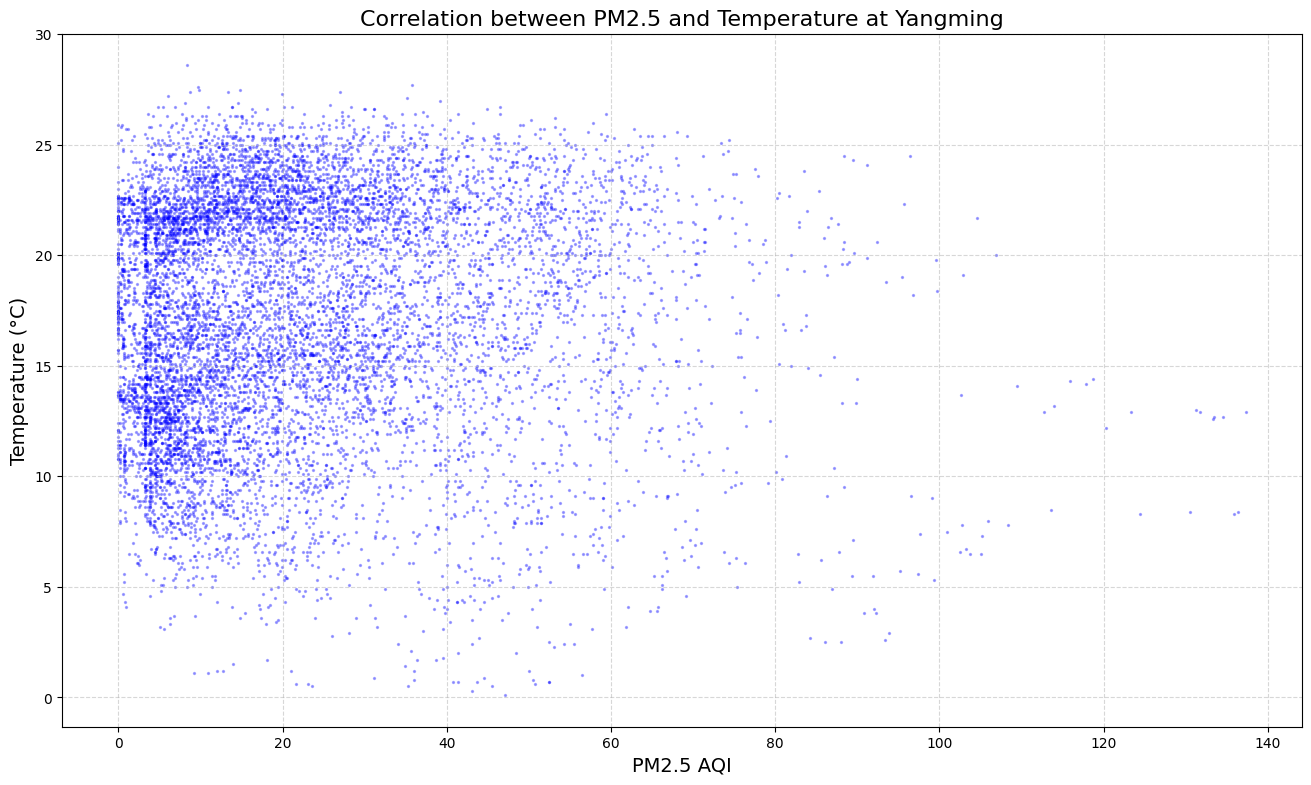

In [85]:
import matplotlib.pyplot as plt

air = []
cli = []

# 1. 修正名稱：去掉 _df
target = "Yangming" 

# 2. 提取資料
# 這裡直接對齊你 dict_keys 裡的名稱格式
for key4, value4 in AQI_dict[f"{target}_temp"].items():
    for key5, value5 in AQI_dict[f"{target}_PM25"].items():
        if key4 == key5:
            # 展開 24 小時的 list
            for t1 in range(len(value4)):
                cli.append(value4[t1])
            for t2 in range(len(value5)):
                air.append(value5[t2])

# 3. 繪圖
plt.figure(figsize=(16, 9))
# 使用 alpha=0.3 可以讓重疊的點看起來更有層次感（熱點圖效果）
plt.scatter(air, cli, s=2, alpha=0.3, color='blue')

plt.title(f"Correlation between PM2.5 and Temperature at {target}", fontsize=16)
plt.xlabel("PM2.5 AQI", fontsize=14)
plt.ylabel("Temperature (°C)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [86]:
def ind(place):
    # 這裡把原本的 "{}_df_CO" 改成 "{}_CO"
    # 因為你的 dict_keys 裡是 'Yangming_CO' 這樣的格式
    
    CO_ = {}
    for key10 , value10 in AQI_dict["{}_CO".format(place)].items():
        # 加入一小段判斷：如果整天沒資料，最大值給 NaN，避免程式報錯
        CO_[key10] = np.nanmax(value10) if not np.all(np.isnan(value10)) else np.nan
        
    O3_ = {}
    for key11 , value11 in AQI_dict["{}_O3".format(place)].items():
        O3_[key11] = np.nanmax(value11) if not np.all(np.isnan(value11)) else np.nan
        
    SO2_ = {}
    for key12 , value12 in AQI_dict["{}_SO2".format(place)].items():
        SO2_[key12] = np.nanmax(value12) if not np.all(np.isnan(value12)) else np.nan
        
    NO2_ = {}
    for key13 , value13 in AQI_dict["{}_NO2".format(place)].items():
        NO2_[key13] = np.nanmax(value13) if not np.all(np.isnan(value13)) else np.nan
        
    PM25_ = {}
    for key14 , value14 in AQI_dict["{}_PM25".format(place)].items():
        PM25_[key14] = np.nanmax(value14) if not np.all(np.isnan(value14)) else np.nan
        
    PM10_ = {}
    for key15 , value15 in AQI_dict["{}_PM10".format(place)].items():
        PM10_[key15] = np.nanmax(value15) if not np.all(np.isnan(value15)) else np.nan
        
    return CO_, O3_, SO2_, NO2_, PM10_, PM25_

In [88]:
def plot(place, air_index):
    # air_index 請傳入整數: 0(CO), 1(O3), 2(SO2), 3(NO2), 4(PM10), 5(PM25)
    # 這是根據你 ind(place) return 的順序
    
    data_source = ind(place)[air_index]
    
    plot_dict = {}  # 用於存月份數據
    plot_dict2 = {} # 用於存每年不良日數 (AQI > 100)
    plot_dict1 = {} # 用於存每年平均數據

    for key16, value16 in data_source.items():
        month_key = key16[0:7] # 例如 "2021-01"
        year_key = key16[0:4]  # 例如 "2021"

        # --- 月份聚合 ---
        if month_key not in plot_dict:
            plot_dict[month_key] = []
        plot_dict[month_key].append(value16)

        # --- 年度不良日數統計 (AQI > 100) ---
        if year_key not in plot_dict2:
            plot_dict2[year_key] = 0
        if not pd.isna(value16) and value16 > 100:
            plot_dict2[year_key] += 1
            
        # --- 年度平均聚合 ---
        if year_key not in plot_dict1:
            plot_dict1[year_key] = []
        plot_dict1[year_key].append(value16)

    # 計算月份平均 (處理 NaN)
    for key17, value17 in plot_dict.items():
        valid_data = [v for v in value17 if not pd.isna(v)]
        plot_dict[key17] = np.mean(valid_data) if valid_data else np.nan

    # 計算年度平均 (處理 NaN)
    for key18, value18 in plot_dict1.items():
        valid_data_yr = [v for v in value18 if not pd.isna(v)]
        plot_dict1[key18] = np.mean(valid_data_yr) if valid_data_yr else np.nan

    # 整理指定的年份清單
    dict_to_list2 = []
    # 這裡可以根據你實際資料的年份動態調整
    yy = ["2018", "2019", "2020", "2021", "2022", "2023", "2024"] 
    for YY in yy:
        dict_to_list2.append(plot_dict2.get(YY, np.nan))
        if YY not in plot_dict1:
            plot_dict1[YY] = np.nan

    # 排序
    plot_dict1 = {k: plot_dict1[k] for k in sorted(plot_dict1)}
    
    return plot_dict, plot_dict1, plot_dict2, dict_to_list2

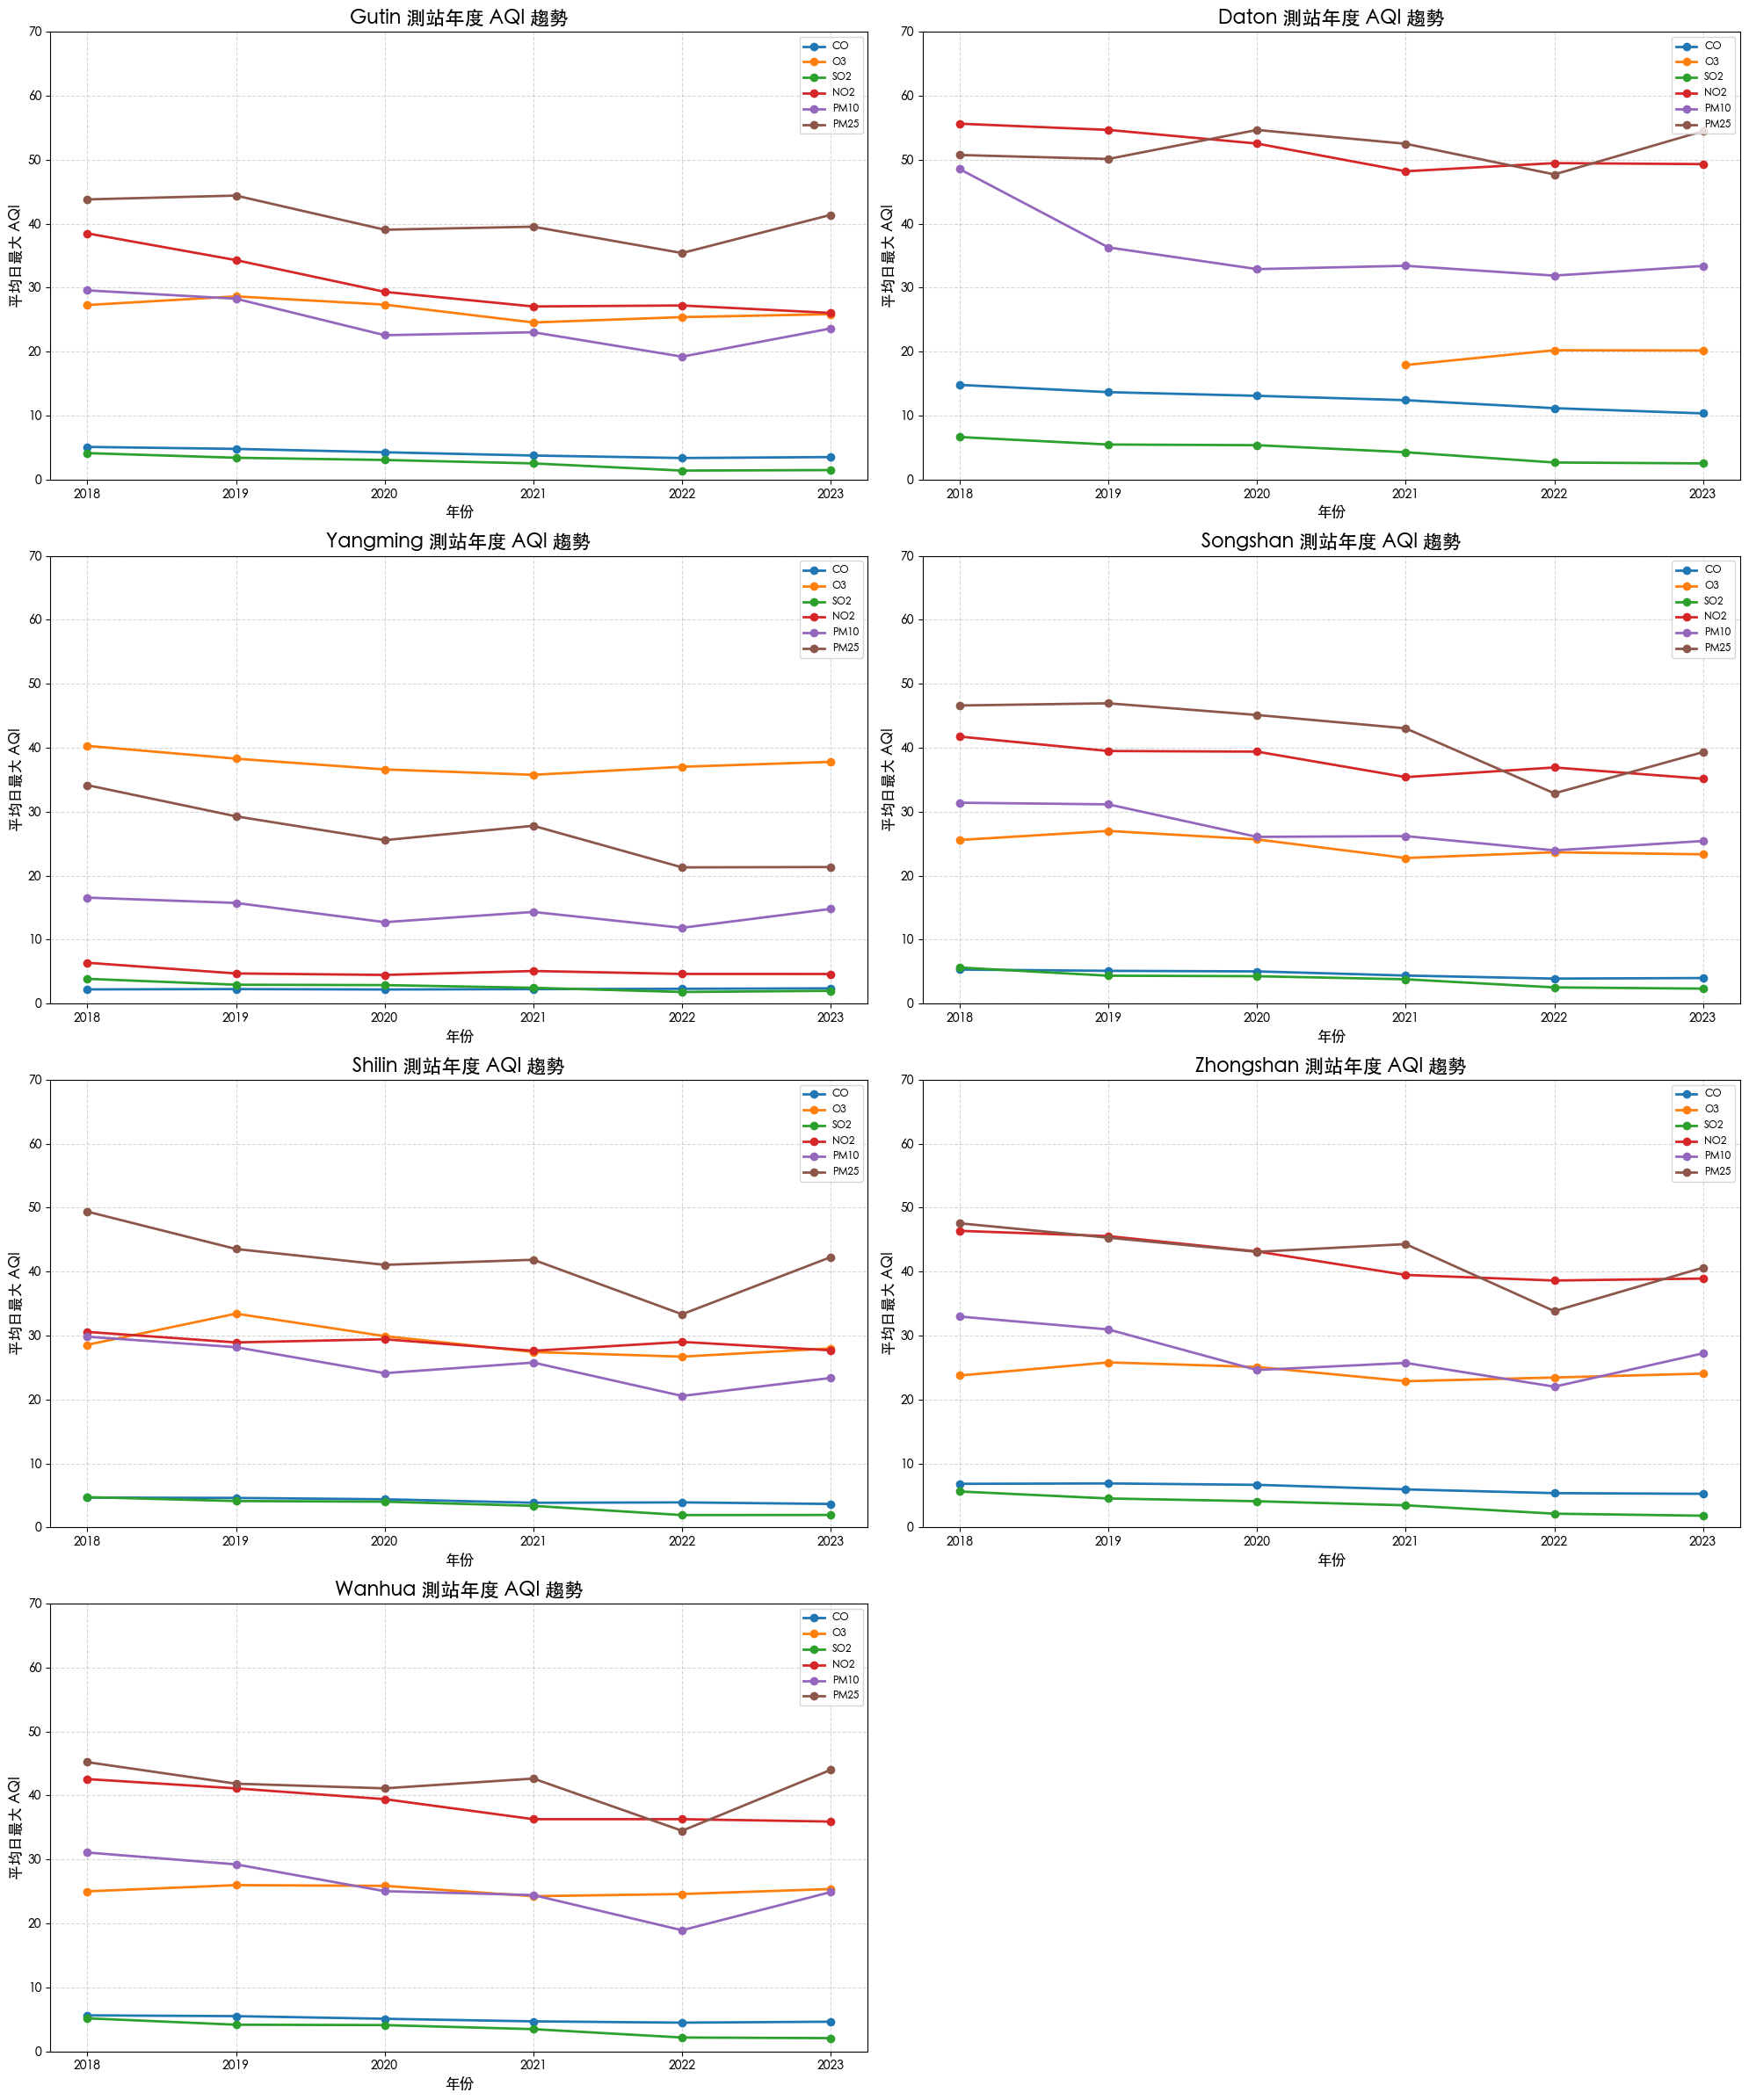

In [98]:
import matplotlib.pyplot as plt

# --- Mac 專用中文顯示設定 ---
plt.rcParams['font.sans-serif'] = ['Heiti TC'] 
plt.rcParams['axes.unicode_minus'] = False 

stations = ["Gutin", "Daton", "Yangming", "Songshan", "Shilin", "Zhongshan", "Wanhua"]
pollutants = ["CO", "O3", "SO2", "NO2", "PM10", "PM25"]

# 建立畫布
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20, 24))
axes = axes.flatten()

for i, site in enumerate(stations):
    ax = axes[i]
    # 這裡的 plot(site, p_idx) 是你之前定義的函式
    for p_idx, p_name in enumerate(pollutants):
        try:
            res = plot(site, p_idx)
            yearly_data = res[1] 
            years = list(yearly_data.keys())
            values = list(yearly_data.values())
            ax.plot(years, values, marker="o", label=p_name, linewidth=2)
        except Exception as e:
            print(f"警告: {site} 的 {p_name} 繪圖失敗: {e}")

    ax.set_title(f"{site} 測站年度 AQI 趨勢", fontsize=16)
    ax.set_xlabel("年份", fontsize=12)
    ax.set_ylabel("平均日最大 AQI", fontsize=12)
    ax.set_ylim(0, 70)
    ax.legend(loc='upper right', fontsize='small')
    ax.grid(True, linestyle='--', alpha=0.5)

# 隱藏多餘的格子
if len(stations) < len(axes):
    axes[-1].axis('off')

plt.tight_layout()
plt.show()

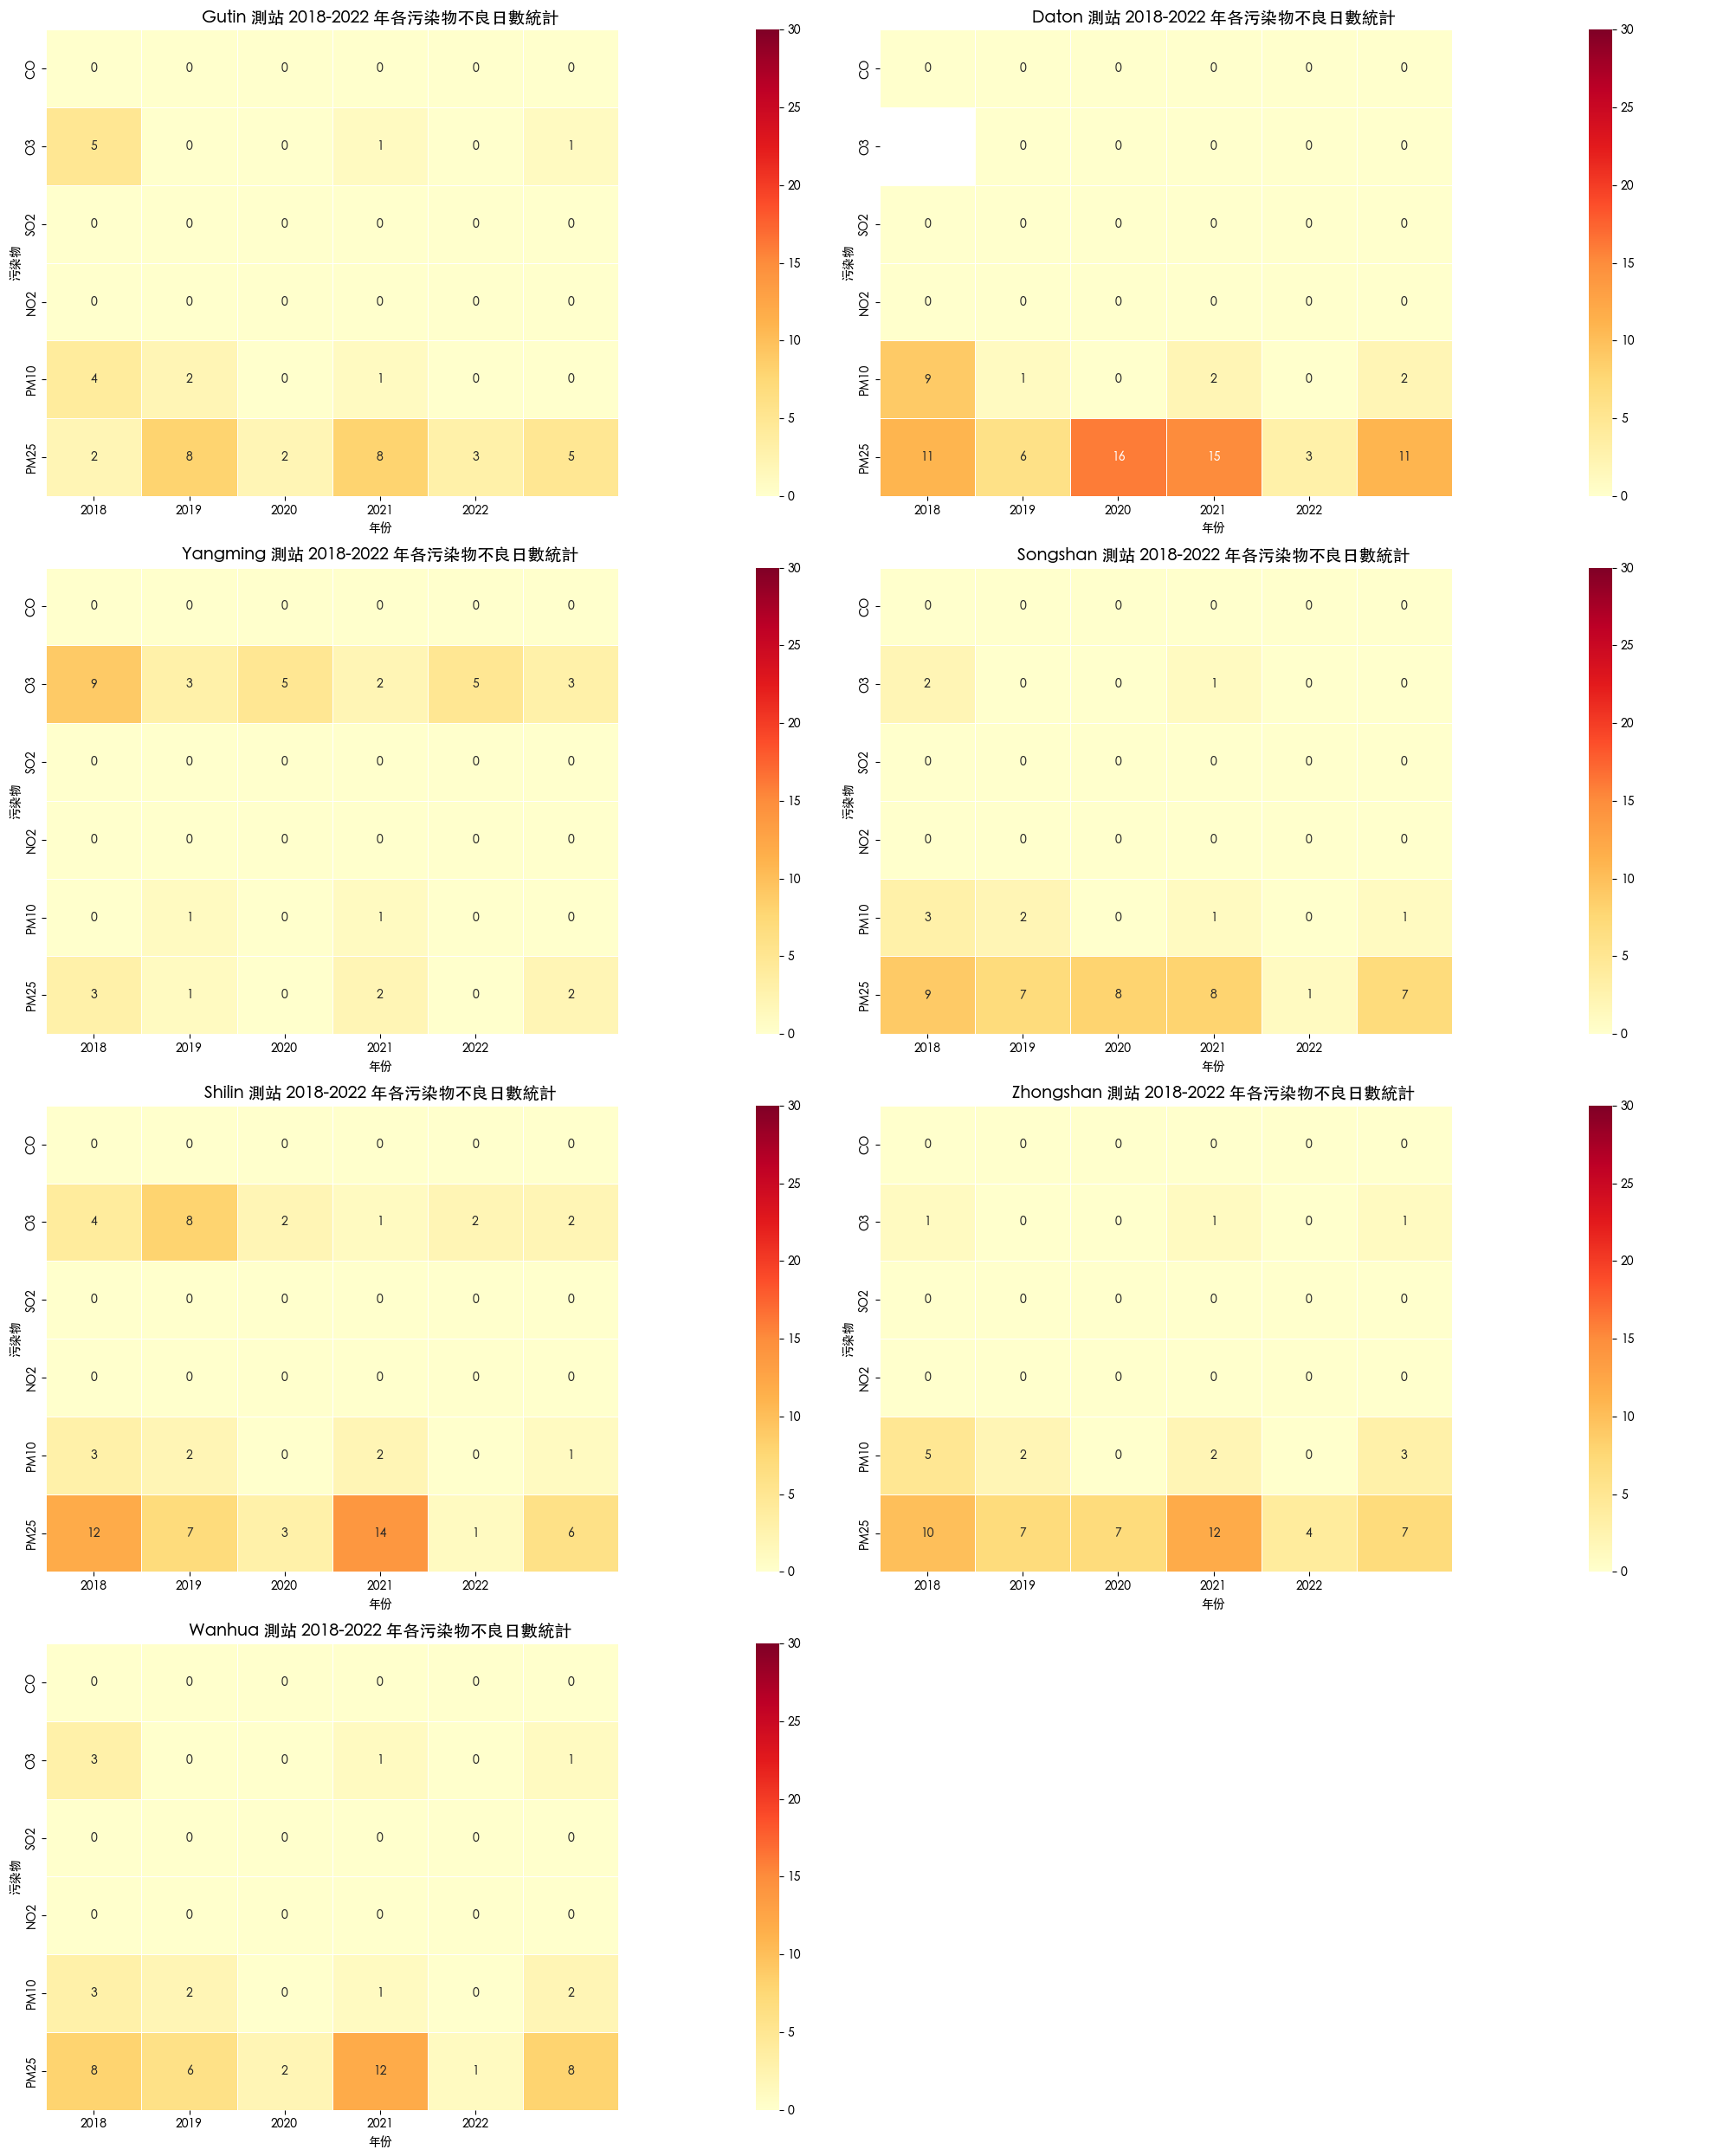

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- Mac 專用中文顯示與負號修正 ---
plt.rcParams['font.sans-serif'] = ['Heiti TC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False 

stations = ["Gutin", "Daton", "Yangming", "Songshan", "Shilin", "Zhongshan", "Wanhua"]
pollutants = ["CO", "O3", "SO2", "NO2", "PM10", "PM25"]
Years = [2018, 2019, 2020, 2021, 2022]

# 建立畫布：4列2行
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20, 25))
axes = axes.flatten()

for i, site in enumerate(stations):
    ax = axes[i]
    
    # 建立該站點的資料表
    # plot(site, idx)[3] 是你原本 return 的 dict_to_list2 (不良日數)
    data_dict = {}
    for idx, name in enumerate(pollutants):
        data_dict[name] = plot(site, idx)[3]
    
    df_heatmap = pd.DataFrame(data_dict).T # 轉置讓污染物在 Y 軸，年份在 X 軸
    
    # 繪製熱圖
    # cbar=True 保留顏色刻度，方便對比數值大小
    sns.heatmap(df_heatmap, 
                annot=True, 
                fmt=".0f", 
                cmap="YlOrRd", # 改用黃-橙-紅，視覺上更符合「警告/不良」的直覺
                xticklabels=Years, 
                yticklabels=pollutants, 
                linewidths=.5, 
                vmin=0, vmax=30, # 統一刻度，一眼看出哪站最紅
                ax=ax)
    
    ax.set_title(f'{site} 測站 2018-2022 年各污染物不良日數統計', fontsize=14)
    ax.set_xlabel('年份')
    ax.set_ylabel('污染物')

# 隱藏多餘的子圖
if len(stations) < len(axes):
    for j in range(len(stations), len(axes)):
        axes[j].axis('off')

plt.tight_layout()
plt.show()

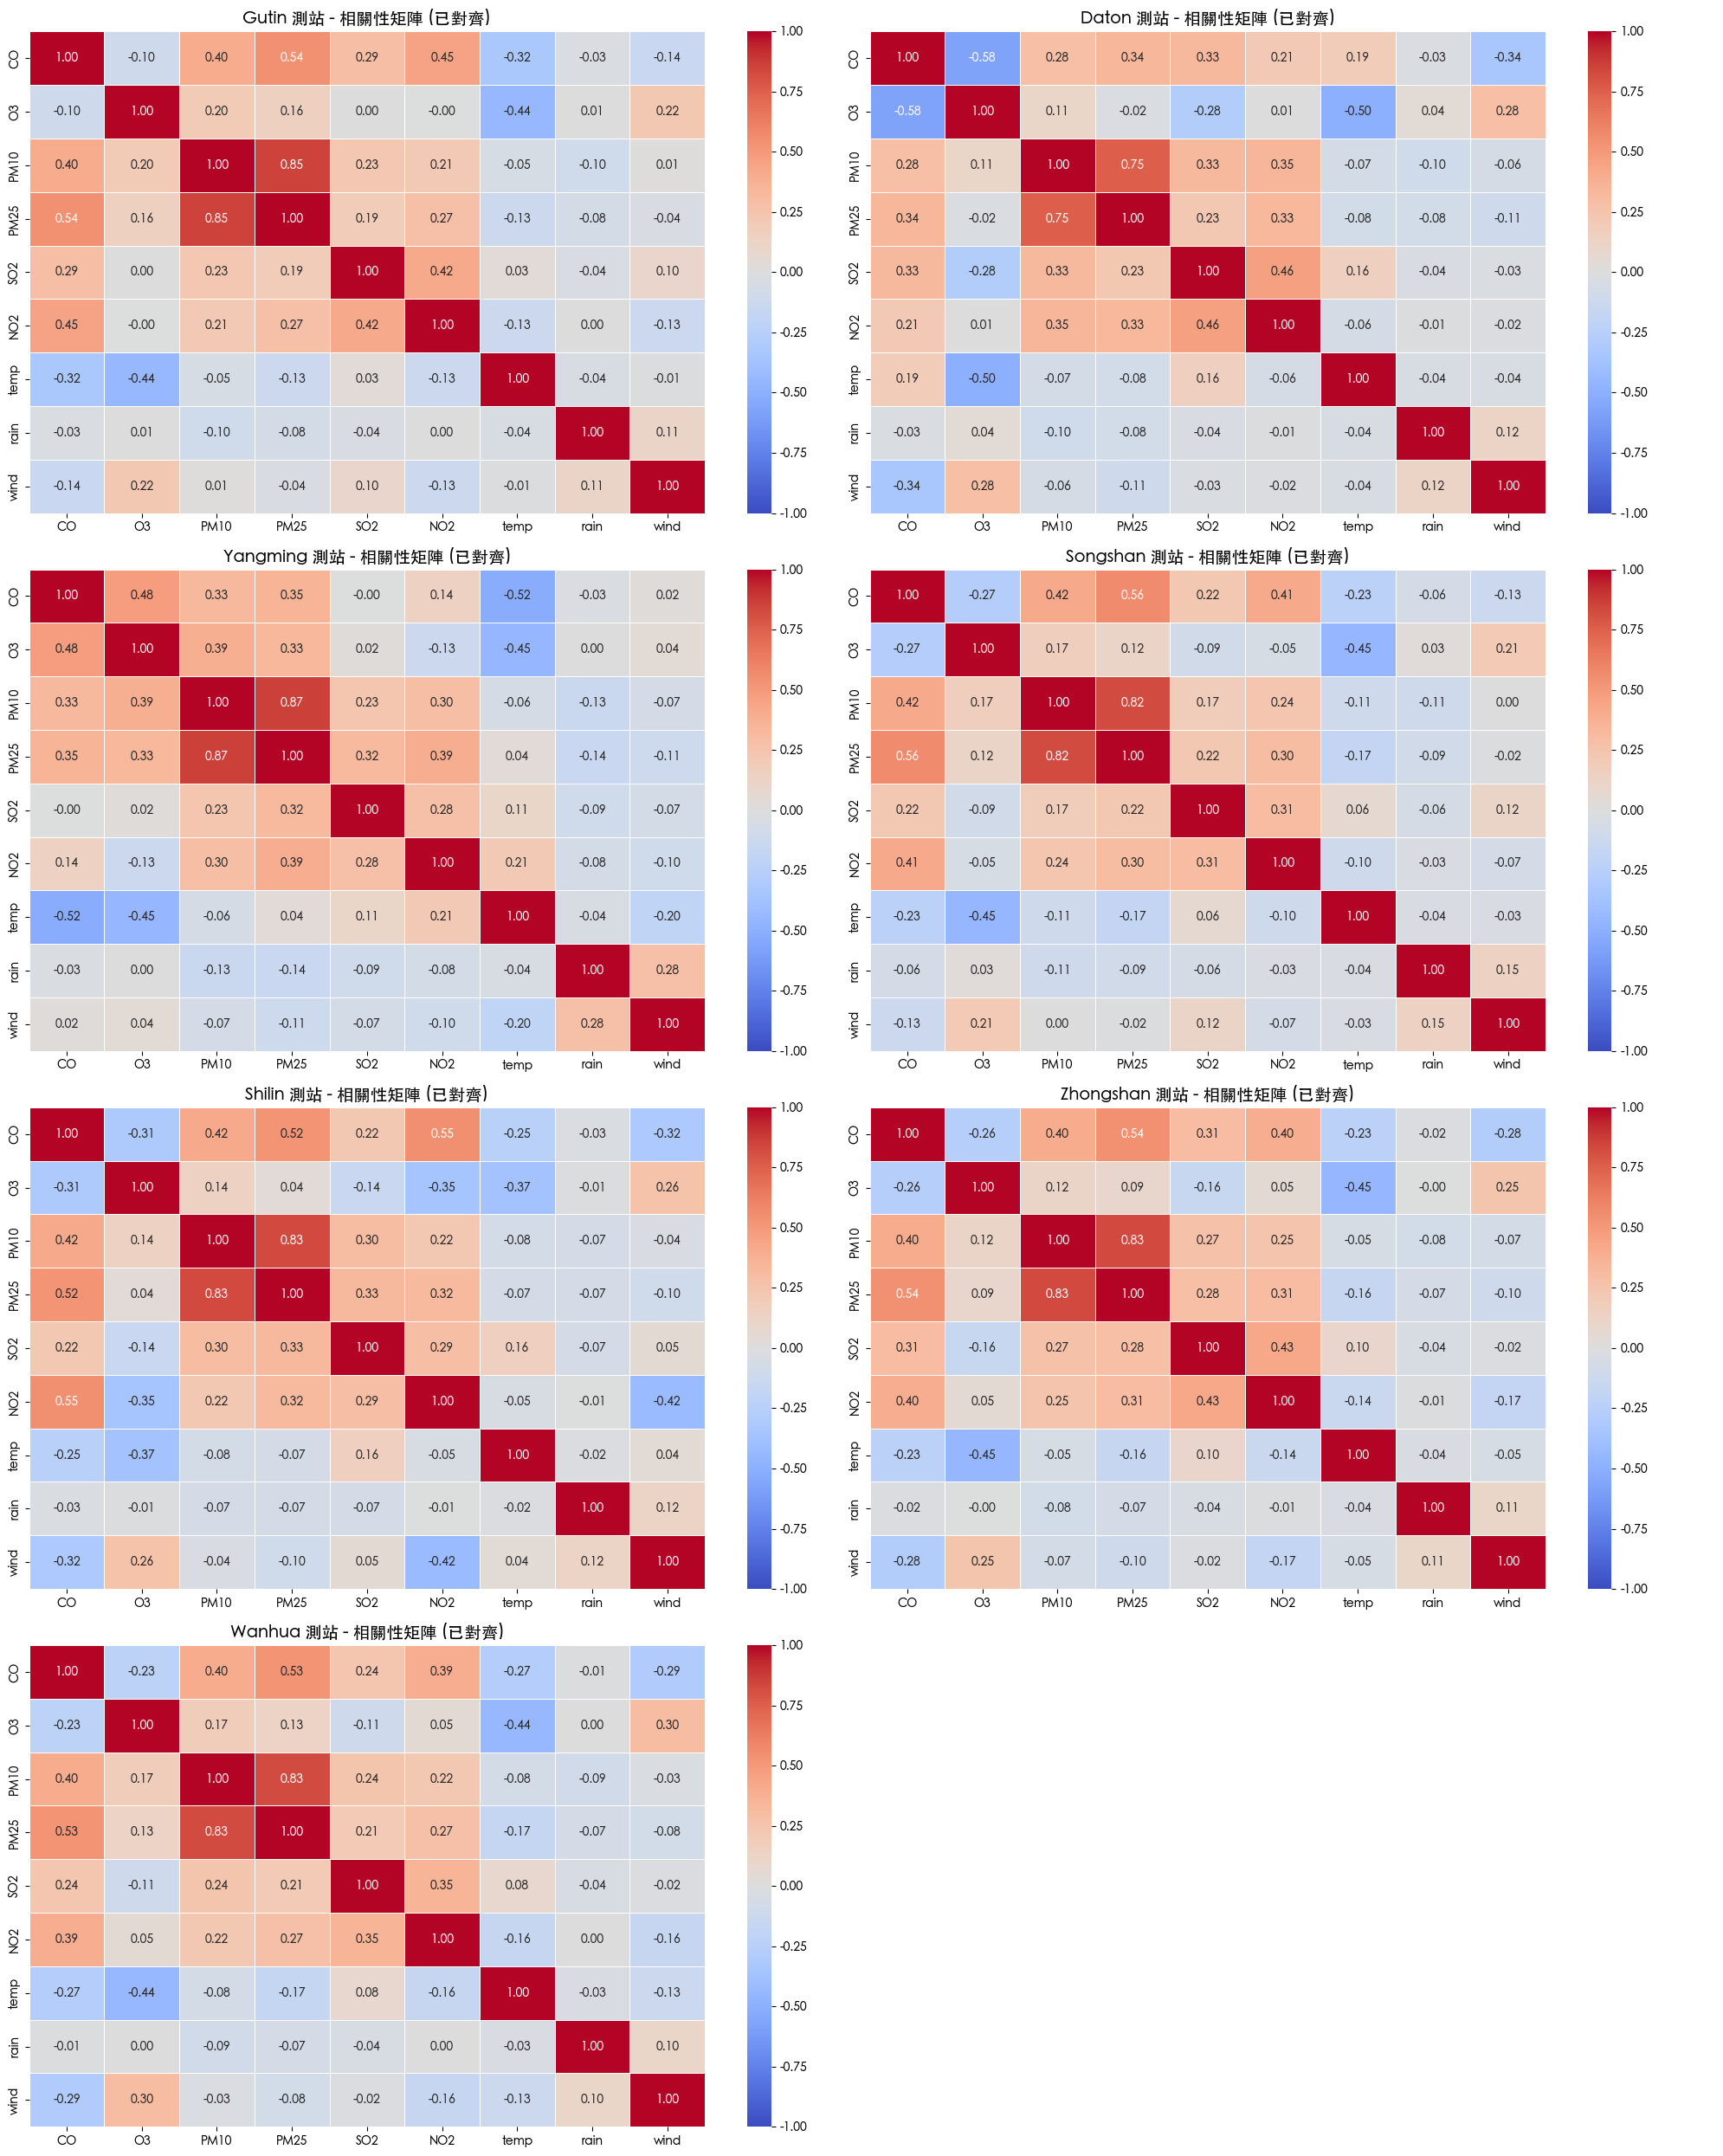

In [102]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- Mac 中文設定 ---
plt.rcParams['font.sans-serif'] = ['Heiti TC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False 

stations = ["Gutin", "Daton", "Yangming", "Songshan", "Shilin", "Zhongshan", "Wanhua"]
metrics = ["CO", "O3", "PM10", "PM25", "SO2", "NO2", "temp", "rain", "wind"]

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20, 25))
axes = axes.flatten()

for i, site in enumerate(stations):
    ax = axes[i]
    site_data_flat = {}
    
    # 1. 取得所有測項的聯集日期 (確保包含所有可能的日期)
    all_dates = set()
    for m in metrics:
        all_dates.update(AQI_dict[f"{site}_{m}"].keys())
    sorted_dates = sorted(list(all_dates))
    
    # 2. 提取數據並強制對齊長度
    for m in metrics:
        flattened_list = []
        source_dict = AQI_dict[f"{site}_{m}"]
        
        for date in sorted_dates:
            # 如果這天沒資料，補 24 個 NaN
            day_data = source_dict.get(date, [np.nan] * 24)
            
            # 如果這天資料不滿 24 小時 (例如只有 10 小時)，補齊到 24 小時
            if len(day_data) < 24:
                day_data = list(day_data) + [np.nan] * (24 - len(day_data))
            
            flattened_list.extend(day_data[:24]) # 確保只取 24 個
            
        site_data_flat[m] = flattened_list
    
    # 3. 建立 DataFrame (現在所有 Array 長度絕對一樣)
    df_temp = pd.DataFrame(site_data_flat)
    
    # 計算相關係數 (會自動忽略 NaN)
    df_corr = df_temp.corr()
    
    # 繪製熱圖
    sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt=".2f", 
                linewidths=.5, vmin=-1, vmax=1, ax=ax)
    
    ax.set_title(f'{site} 測站 - 相關性矩陣 (已對齊)', fontsize=14)

# 隱藏多餘子圖
for j in range(len(stations), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

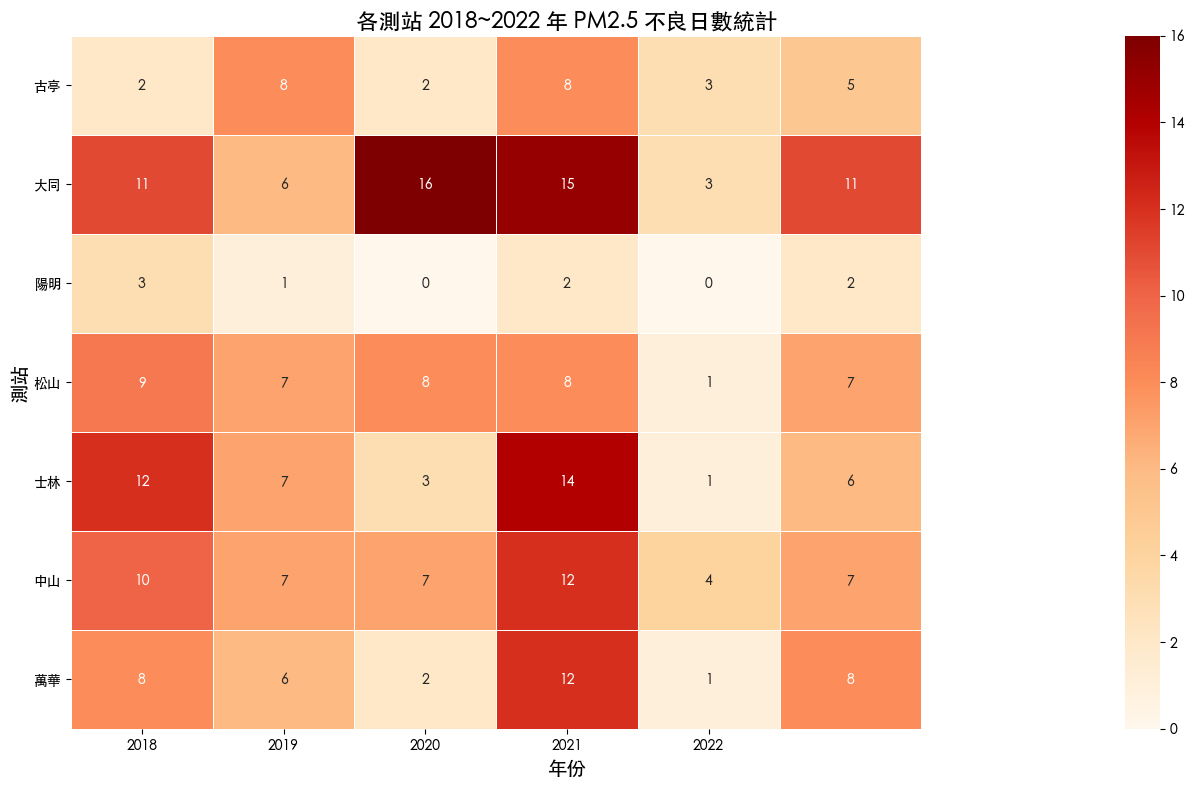

In [103]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Mac 中文顯示設定 ---
plt.rcParams['font.sans-serif'] = ['Heiti TC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False 

# 1. 準備數據：建立各測站對比表
stations = ["Gutin", "Daton", "Yangming", "Songshan", "Shilin", "Zhongshan", "Wanhua"]
stations_cn = ["古亭", "大同", "陽明", "松山", "士林", "中山", "萬華"]
Years = [2018, 2019, 2020, 2021, 2022]

# 假設我們要比較的是 PM2.5 (index 5) 的不良日數
target_pollutant_index = 5 
target_pollutant_name = "PM2.5"

all_station_data = {}

for site_en, site_cn in zip(stations, stations_cn):
    # 使用你定義的 plot 函式，取 index 3 (即 dict_to_list2 不良日數)
    bad_days_list = plot(site_en, target_pollutant_index)[3]
    all_station_data[site_cn] = bad_days_list

# 建立 DataFrame 並轉置，讓測站在 Y 軸，年份在 X 軸
AQI_ALL = pd.DataFrame(all_station_data).T

# 2. 繪圖
plt.figure(figsize=(16, 9))
sns.heatmap(AQI_ALL, 
            annot=True, 
            fmt=".0f", # 天數顯示為整數
            cmap="OrRd", # 使用橘紅系色調，更能體現「不良日數」的警示感
            xticklabels=Years, 
            yticklabels=AQI_ALL.index, 
            linewidths=.5)

plt.title(f'各測站 2018~2022 年 {target_pollutant_name} 不良日數統計', fontsize=16)
plt.xlabel('年份', fontsize=14)
plt.ylabel('測站', fontsize=14)
plt.yticks(rotation='horizontal')
plt.show()

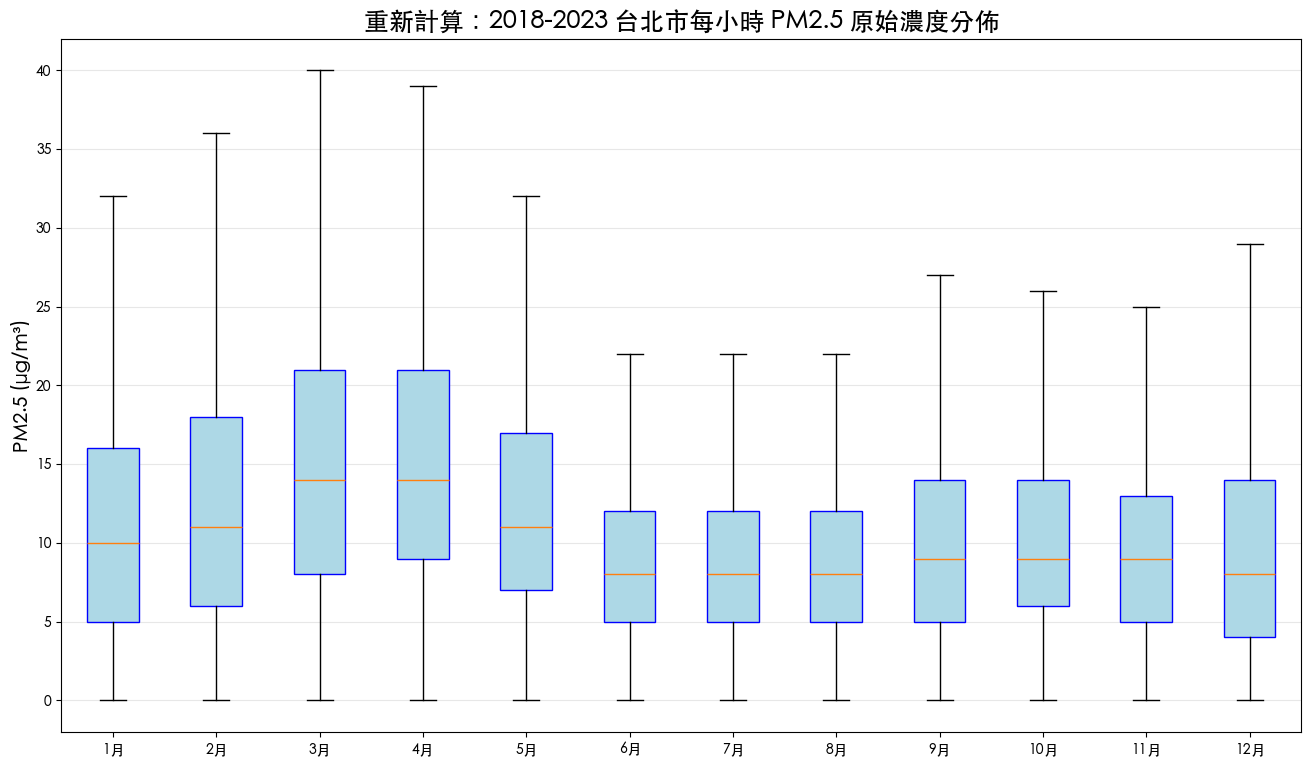

In [151]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

all_raw_pm25_by_month = [[] for _ in range(12)]

# 遍歷原始 store_dict
for key, df in store_dict.items():
    # 1. 確保只抓 PM2.5 
    # 注意：有些年份可能叫 'PM2.5'，有些叫 'PM25'，這裡做個兼容
    pm25_df = df[df['測項'].str.contains('PM2.5|PM25', na=False, case=False)].copy()
    
    # 2. 轉換日期
    pm25_df['日期'] = pd.to_datetime(pm25_df['日期'])
    
    # 取得當前 df 的所有欄位名稱，方便比對
    cols = pm25_df.columns.tolist()

    for _, row in pm25_df.iterrows():
        month_idx = row['日期'].month - 1
        hourly_data = []
        
        for h in range(24):
            # 嘗試各種可能的欄位名稱格式
            possible_keys = [h, str(h), f"{h:02d}", f"{h:02d}:00", f"{h}:00"]
            
            target_col = None
            for p_key in possible_keys:
                if p_key in row.index: # 在 Series (row) 中檢查 index
                    target_col = p_key
                    break
            
            if target_col is not None:
                # 轉為數字，'coerce' 會把不可計算的 (如空值、#、*) 轉為 NaN
                val = pd.to_numeric(row[target_col], errors='coerce')
                if pd.notna(val):
                    hourly_data.append(val)
        
        if hourly_data:
            all_raw_pm25_by_month[month_idx].extend(hourly_data)

# 3. 繪製盒鬚圖
plt.figure(figsize=(16, 9))
plt.boxplot(all_raw_pm25_by_month, 
            labels=['1月','2月','3月','4月','5月','6月','7月','8月','9月','10月','11月','12月'],
            showfliers=False,  # 隱藏極端值讓圖表好看一點
            patch_artist=True,
            boxprops=dict(facecolor='#ADD8E6', color='blue'))

plt.title('重新計算：2018-2023 台北市每小時 PM2.5 原始濃度分佈', fontsize=18)
plt.ylabel('PM2.5 (μg/m³)', fontsize=14)
plt.grid(True, axis='y', alpha=0.3)
plt.show()

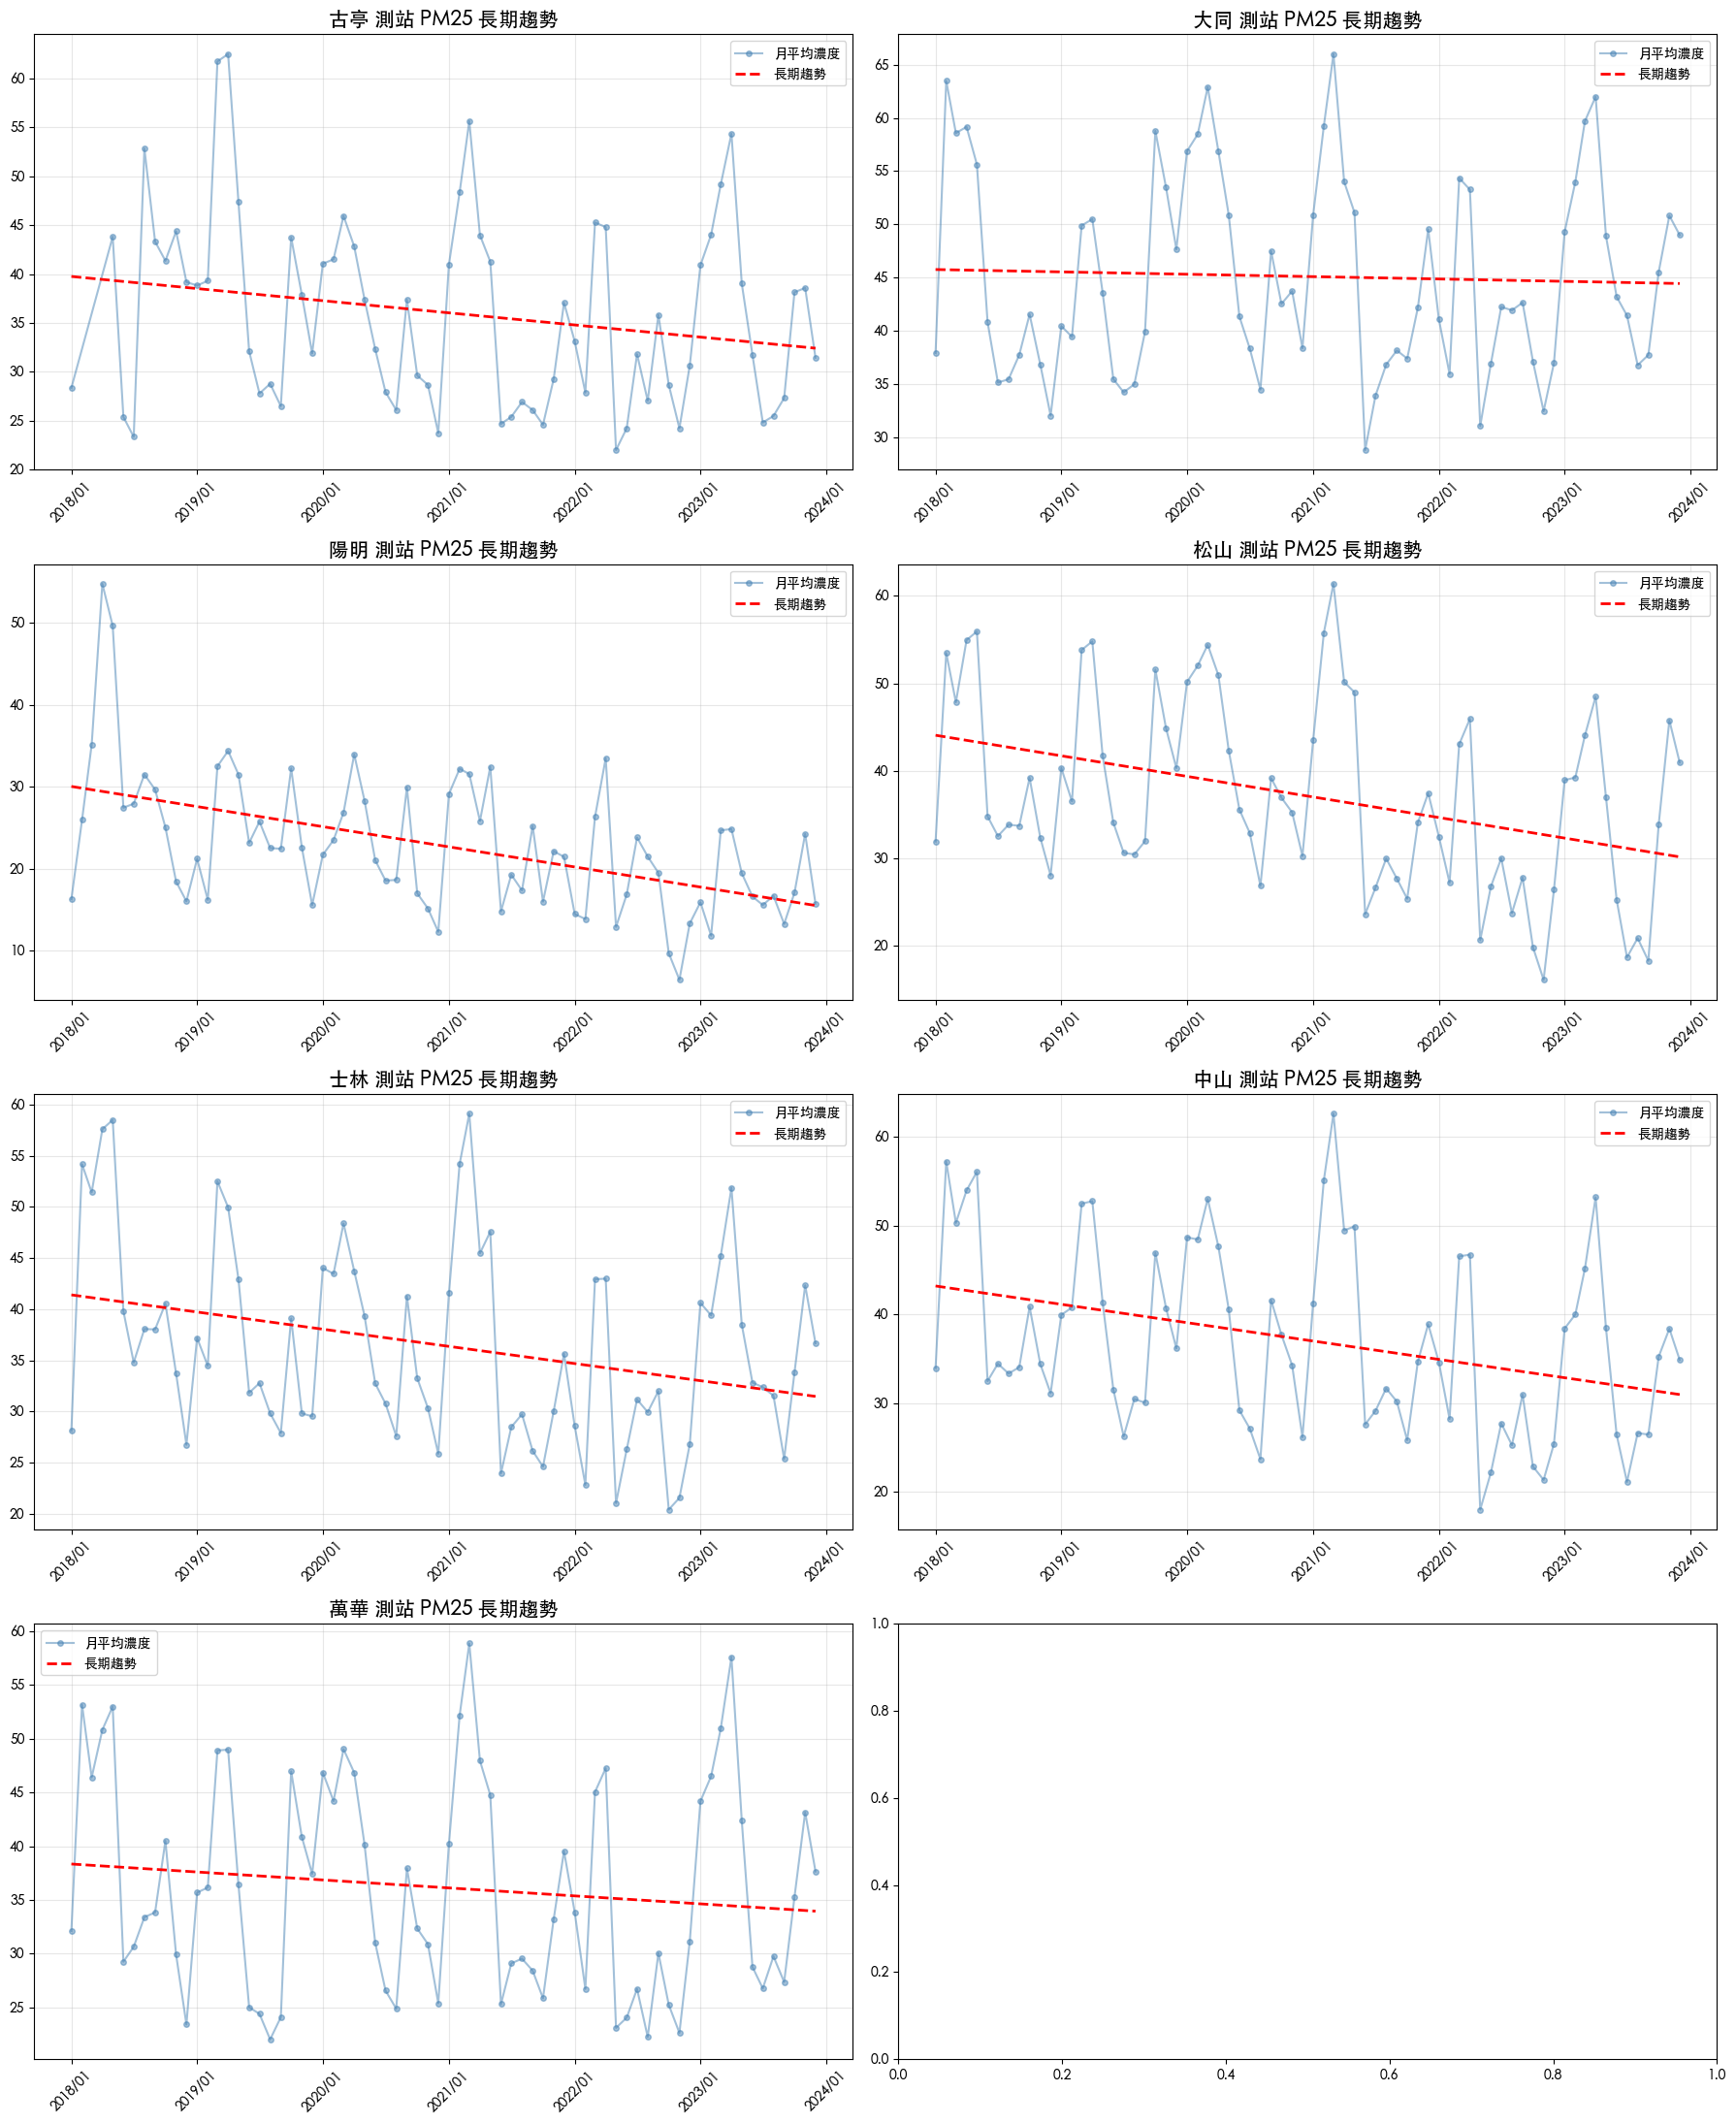

In [115]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import numpy as np
import pandas as pd

# --- 1. Mac 中文環境設定 ---
plt.rcParams['font.sans-serif'] = ['Heiti TC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False 

# --- 2. 設定參數 ---
stations = {
    "Gutin": "古亭", "Daton": "大同", "Yangming": "陽明", 
    "Songshan": "松山", "Shilin": "士林", "Zhongshan": "中山", "Wanhua": "萬華"
}
target = "PM25"

# --- 3. 開始繪圖與計算 ---
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(18, 22))
axes = axes.flatten()

for i, (en_name, cn_name) in enumerate(stations.items()):
    ax = axes[i]
    
    # 從 AQI_dict 尋找正確的 Key
    data_key = next((k for k in AQI_dict if en_name.lower() in k.lower() and target.lower() in k.lower()), None)
    
    if data_key:
        raw_data = AQI_dict[data_key]
        month_avg_dict = {}
        
        for date_str, values in raw_data.items():
            try:
                # --- 核心修正：使用 pd.to_datetime 自動辨識格式 ---
                dt_obj = pd.to_datetime(date_str)
                month = dt_obj.strftime('%Y/%m') # 統一轉為 YYYY/MM 格式做 Key
                
                clean_vals = [v for v in values if v is not None and not (isinstance(v, float) and np.isnan(v))]
                if not clean_vals: continue
                
                if month not in month_avg_dict:
                    month_avg_dict[month] = []
                month_avg_dict[month].extend(clean_vals)
            except:
                continue
            
        if not month_avg_dict:
            ax.set_title(f"{cn_name} 無有效日期數據")
            continue

        # 整理序列
        sorted_months = sorted(month_avg_dict.keys())
        dates = [datetime.strptime(m, '%Y/%m') for m in sorted_months]
        averages = [np.mean(month_avg_dict[m]) for m in sorted_months]
        
        # --- 繪圖 ---
        ax.plot(dates, averages, marker='o', markersize=4, alpha=0.5, color='steelblue', label='月平均濃度')
        
        # 趨勢線
        x_nums = mdates.date2num(dates)
        slope, intercept = np.polyfit(x_nums, averages, 1)
        ax.plot(dates, slope * x_nums + intercept, color='red', linestyle='--', linewidth=2, label='長期趨勢')
        
        ax.set_title(f'{cn_name} 測站 {target} 長期趨勢', fontsize=15)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y/%m'))
        ax.tick_params(axis='x', rotation=45)
        ax.legend()
        ax.grid(True, alpha=0.3)
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

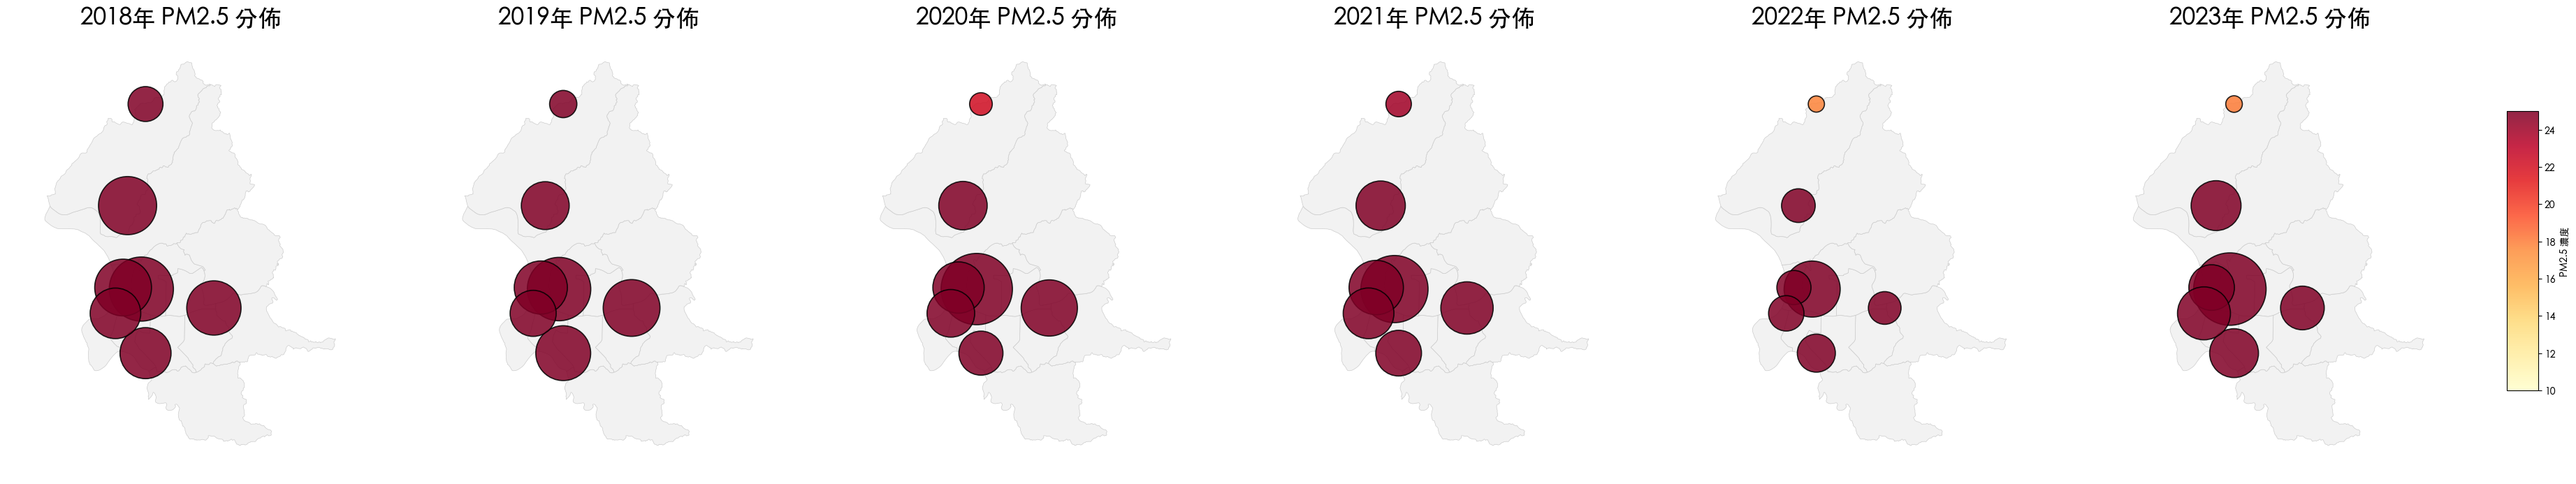

In [148]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# 1. 座標與底圖設定 (座標請務必對齊 WGS84)
stations_pos = {
    "古亭": (121.5295, 25.0206), "大同": (121.5265, 25.0623),
    "陽明": (121.5295, 25.1827), "松山": (121.5786, 25.0500),
    "士林": (121.5166, 25.1166), "中山": (121.5134, 25.0633),
    "萬華": (121.5079, 25.0465)
}

shp_path = r'/Users/kai_0514/Documents/Python/final project_air pollution/TPE_shape/TPE_TOWN.shp'
base_map = gpd.read_file(shp_path).to_crs(epsg=4326)

# 2. 繪圖設定
plt.rcParams['font.sans-serif'] = ['Heiti TC', 'Arial Unicode MS']
years = [2018, 2019, 2020, 2021, 2022, 2023]
fig, axes = plt.subplots(1, 6, figsize=(45, 10))

for idx, year in enumerate(years):
    ax = axes[idx]
    base_map.plot(ax=ax, color='#f2f2f2', edgecolor='#cccccc', linewidth=0.5)
    
    # 從你跑出來的 df_summary 抓取該年度所有測站數據
    year_data = df_summary.loc[year]
    
    lons, lats, aqis = [], [], []
    for cn_name, pos in stations_pos.items():
        val = year_data.get(cn_name, 0)
        if pd.notna(val) and val > 0:
            aqis.append(val)
            lons.append(pos[0])
            lats.append(pos[1])

    # 3. 視覺強化核心：非線性放大 + 窄色域
    if aqis:
        # 強制放大差距：AQI 的 3.5 次方
        m_sizes = (np.array(aqis)**3) * 0.05 
        
        # 繪製氣泡 (vmin/vmax 越窄，顏色變化越劇烈)
        scatter = ax.scatter(lons, lats, s=m_sizes, c=aqis, cmap='YlOrRd', 
                            alpha=0.85, edgecolors='black', linewidth=1.2, 
                            vmin=10, vmax=25, zorder=5)

    ax.set_xlim([121.43, 121.68])
    ax.set_ylim([24.94, 25.23])
    ax.set_title(f"{year}年 PM2.5 分佈", fontsize=24, fontweight='bold')
    ax.axis('off')

# 加上顏色條方便對照
cbar_ax = fig.add_axes([0.92, 0.3, 0.01, 0.4])
fig.colorbar(scatter, cax=cbar_ax, label='PM2.5 濃度')

plt.show()